In [5]:
import pandas as pd

df1 = pd.read_csv(r"C:\realityos_you day analyzer\data\dataset\ScreenTime vs MentalWellness.csv", encoding="latin1")
df2 = pd.read_csv(r"C:\realityos_you day analyzer\data\dataset\student_productivity_distraction_dataset_20000.csv", encoding="latin1")

print(df1.head())
print(df2.head())

  user_id  age  gender occupation  work_mode  screen_time_hours  \
0   U0001   33  Female   Employed     Remote              10.79   
1   U0002   28  Female   Employed  In-person               7.40   
2   U0003   35  Female   Employed     Hybrid               9.78   
3   U0004   42    Male   Employed     Hybrid              11.13   
4   U0005   28    Male    Student     Remote              13.22   

   work_screen_hours  leisure_screen_hours  sleep_hours  sleep_quality_1_5  \
0               5.44                  5.35         6.63                  1   
1               0.37                  7.03         8.05                  3   
2               1.09                  8.69         6.48                  1   
3               0.56                 10.57         6.89                  1   
4               4.09                  9.13         5.79                  1   

   stress_level_0_10  productivity_0_100  exercise_minutes_per_week  \
0                9.3                44.7                 

clean your code

In [6]:
df1 = df1.loc[:,df1.columns.str.contains("Unnamed")]

Step 2: Identify useful features

In [7]:
features1 = [
    "age",
    "mental_wellness_index_0_100"
]

Dataset 2 (Productivity)

In [8]:
features2 = [
    "study_hours",
    "distraction_time",
    "sleep_hours",
    "focus_score",
    "productivity_score"
]

Step 3: Verify columns

In [9]:
print(df1.columns)
print(df2.columns)

Index(['Unnamed: 15'], dtype='object')
Index(['student_id', 'age', 'gender', 'study_hours_per_day', 'sleep_hours',
       'phone_usage_hours', 'social_media_hours', 'youtube_hours',
       'gaming_hours', 'breaks_per_day', 'coffee_intake_mg',
       'exercise_minutes', 'assignments_completed', 'attendance_percentage',
       'stress_level', 'focus_score', 'final_grade', 'productivity_score'],
      dtype='object')


Step 4: Correlation

In [10]:
# Correct the features list for correlation
corrected_features2 = [
    "study_hours_per_day",
    "sleep_hours",
    "focus_score",
    "productivity_score"
]
print(df2[corrected_features2].corr())

                     study_hours_per_day  sleep_hours  focus_score  \
study_hours_per_day             1.000000     0.001670     0.004536   
sleep_hours                     0.001670     1.000000    -0.003241   
focus_score                     0.004536    -0.003241     1.000000   
productivity_score              0.732777     0.340902     0.411366   

                     productivity_score  
study_hours_per_day            0.732777  
sleep_hours                    0.340902  
focus_score                    0.411366  
productivity_score             1.000000  


step 5 clustering

In [11]:
from sklearn.preprocessing import StandardScaler

X = df2[corrected_features2]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Apply KMEANS

In [12]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df2["cluster"] = kmeans.fit_predict(X_scaled)

Step 6: Interpret clusters

In [13]:
print(df2.groupby("cluster")[corrected_features2].mean())

         study_hours_per_day  sleep_hours  focus_score  productivity_score
cluster                                                                   
0                   3.275901     6.580252    81.711294           47.389572
1                   7.915148     6.948691    66.884408           64.603813
2                   3.669308     5.928251    46.405414           34.689076


Add anomaly detection

In [14]:
import numpy as np

scores = df2["productivity_score"]

mean = np.mean(scores)
std = np.std(scores)

df2["anomaly"] = df2["productivity_score"] < (mean - 2*std)

BUILD FINAL OUTPUT (THIS IS YOUR PRODUCT)

In [15]:
def generate_recommendation(row):
    if row["cluster"] == 2:
        return "Reduce distractions and improve sleep"
    elif row["cluster"] == 0:
        return "Increase study time"
    else:
        return "Maintain current routine"

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\realityos_you day analyzer\data\dataset\student_productivity_distraction_dataset_20000.csv")

print(df.head())
print(df.info())

   student_id  age  gender  study_hours_per_day  sleep_hours  \
0           1   23  Female                 4.35         3.63   
1           2   20    Male                 6.14         6.58   
2           3   29  Female                 4.98         3.26   
3           4   27  Female                 3.19         4.58   
4           5   24    Male                 7.67         6.21   

   phone_usage_hours  social_media_hours  youtube_hours  gaming_hours  \
0               3.38                2.73           1.83          5.26   
1               5.48                1.51           3.13          1.73   
2               4.83                3.63           0.18          4.71   
3              10.06                3.95           5.75          2.52   
4               3.02                1.59           5.46          5.65   

   breaks_per_day  coffee_intake_mg  exercise_minutes  assignments_completed  \
0               6               347               111                      2   
1              1

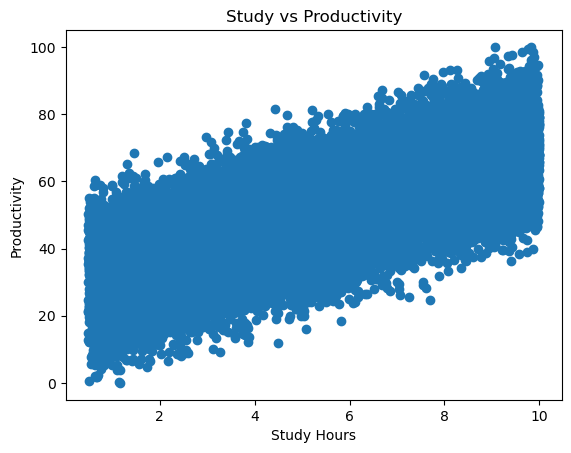

In [18]:
plt.scatter(df['study_hours_per_day'], df['productivity_score'])
plt.xlabel("Study Hours")
plt.ylabel("Productivity")
plt.title("Study vs Productivity")
plt.show()

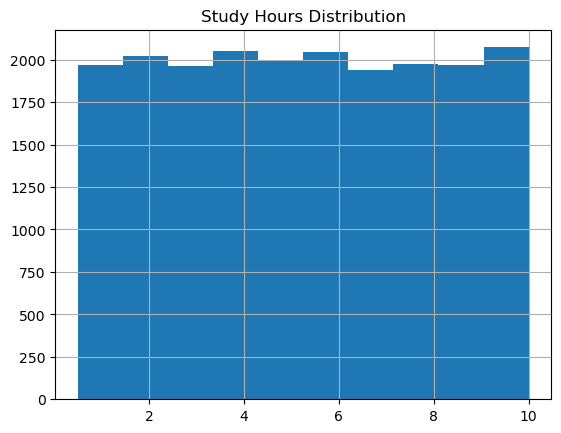

In [20]:
df['study_hours_per_day'].hist()
plt.title("Study Hours Distribution")
plt.show()